# 01 — Replicating Fama & French (1993)

This notebook rebuilds the paper's core evidence from public data (Ken French Data Library). Every number here is recomputed live; the full pipeline (`scripts/run_all.py`) produces the same numbers as tables and figures.

**The model.** For any portfolio $i$ with excess return $R_{i,t}-R_{f,t}$:

$$R_{i,t}-R_{f,t} = a_i + b_i(R_{M,t}-R_{f,t}) + s_i\,SMB_t + h_i\,HML_t + e_{i,t}$$

If the three factors price assets, every intercept $a_i$ is zero: average returns are fully explained by *exposure* (b, s, h) times the factors' average premia.

In [1]:
import numpy as np, pandas as pd
from IPython.display import Image, display
from factor_neutrality import data, factors, regression as rg, strategy as st, performance as pf
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 160)
ROOT = __import__("pathlib").Path.cwd().parent
TAB, FIG = ROOT / "results" / "tables", ROOT / "results" / "figures"


## 1. Rebuild SMB and HML from the six size/BE-ME portfolios

$SMB = \tfrac13(S/L+S/M+S/H)-\tfrac13(B/L+B/M+B/H)$ and $HML=\tfrac12(S/H+B/H)-\tfrac12(S/L+B/L)$ (FF93, §2.1.2).

In [2]:
ff3 = data.ff3()
rebuilt = factors.smb_hml(data.six_portfolios())
cmp = pd.concat({"rebuilt": rebuilt, "published": ff3[["SMB", "HML"]]}, axis=1).dropna()
for c in ["SMB", "HML"]:
    a, b = cmp[("rebuilt", c)], cmp[("published", c)]
    print(f"{c}: corr = {a.corr(b):.5f}, RMSE = {1e4*np.sqrt(((a-b)**2).mean()):.2f} bp/month, months = {len(a)}")

SMB: corr = 1.00000, RMSE = 0.30 bp/month, months = 1202
HML: corr = 1.00000, RMSE = 0.29 bp/month, months = 1202


## 2. FF93 Table 2: factor premia, July 1963 – December 1991 (342 months)

In [3]:
IS = slice("1963-07", "1991-12")
f = ff3.loc[IS]
t2 = pd.DataFrame({c: {"mean %/mo": 100*f[c].mean(), "sd %/mo": 100*f[c].std(),
                       "t(mean)": f[c].mean()/f[c].std()*np.sqrt(len(f))} for c in ["Mkt-RF", "SMB", "HML"]}).T
t2["FF93 mean"] = [0.43, 0.27, 0.40]; t2["FF93 t"] = [1.76, 1.73, 2.91]
t2

,mean %/mo,sd %/mo,t(mean),FF93 mean,FF93 t
Mkt-RF,0.411,4.592,1.654,0.430,1.760
SMB,0.259,2.864,1.674,0.270,1.730
HML,0.378,2.539,2.750,0.400,2.910


Small differences come from CRSP/Compustat revisions since 1992 (the data vintage here is the 2026 CRSP file); the economic picture is identical: a large but statistically marginal market premium, a weak size premium, and a reliable value premium.

## 3. CAPM vs. three-factor regressions on the 25 portfolios, and the GRS test

The Gibbons–Ross–Shanken statistic tests $H_0: a_1=\dots=a_N=0$ jointly:
$$F=\frac{T-N-K}{N}\,\frac{\hat a'\hat\Sigma^{-1}\hat a}{1+\bar f'\hat\Omega^{-1}\bar f}\sim F(N,\,T-N-K)$$
The denominator penalises factors with high Sharpe ratios: alphas look less surprising when the factors themselves are very profitable.

In [4]:
ex = data.portfolios_25().sub(ff3["RF"], axis=0).loc[IS]
for name, cols in [("CAPM", ["Mkt-RF"]), ("FF3", ["Mkt-RF", "SMB", "HML"])]:
    g = rg.grs(ex, f[cols])
    print(f"{name}: GRS F = {g['F']:.2f} (p = {g['p']:.3f}), mean |alpha| = {100*g['mean_abs_alpha']:.3f}%/month")
print("FF93 Table 9c (32 assets incl. bonds): CAPM 1.91, FF3 1.56")

CAPM: GRS F = 1.98 (p = 0.004), mean |alpha| = 0.257%/month
FF3: GRS F = 1.43 (p = 0.086), mean |alpha| = 0.094%/month
FF93 Table 9c (32 assets incl. bonds): CAPM 1.91, FF3 1.56


In [5]:
a = pd.DataFrame({p: {"CAPM a": 100*rg.fit(ex[p], f[["Mkt-RF"]], hac=False).alpha,
                       "FF3 a": 100*rg.fit(ex[p], f[["Mkt-RF","SMB","HML"]], hac=False).alpha,
                       "FF3 t": rg.fit(ex[p], f[["Mkt-RF","SMB","HML"]], hac=False).alpha_t} for p in ex}).T
a.loc[["S1B1", "S1B5", "S5B1", "S5B5"]]  # corners; FF93: S1B1 FF3 a = -0.34 (t=-3.16), S5B1 = 0.21 (3.27)

,CAPM a,FF3 a,FF3 t
S1B1,-0.265,-0.368,-3.428
S1B5,0.538,0.058,0.879
S5B1,-0.043,0.193,2.861
S5B5,0.172,-0.172,-1.597


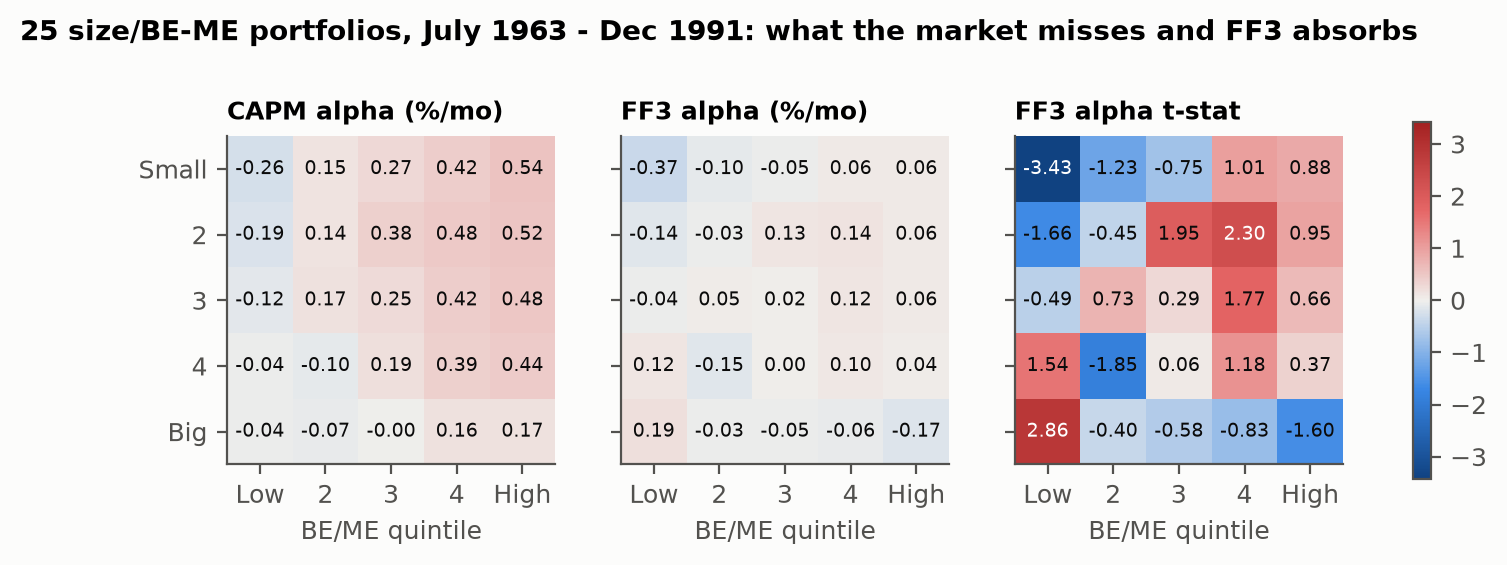

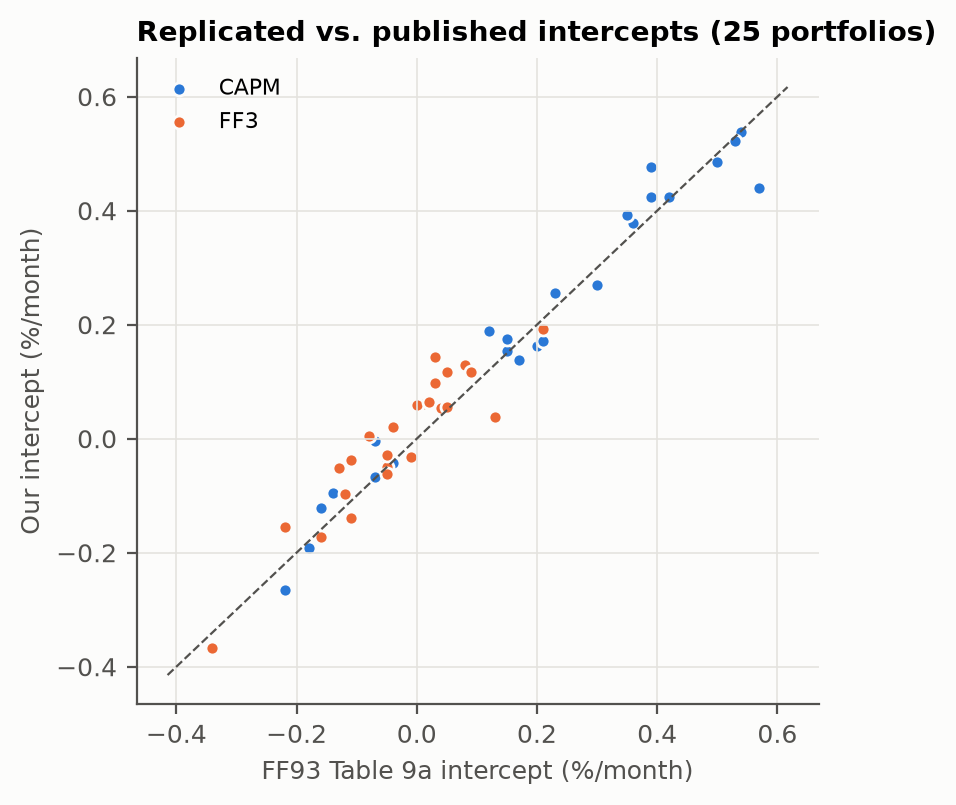

In [6]:
display(Image(FIG / 'F03_alpha_heatmaps_is.png')); display(Image(FIG / 'F05_intercepts_vs_ff93.png'))

**Reading.** CAPM intercepts rise with BE/ME and fall with size (the anomalies FF93 set out to explain). Adding SMB and HML collapses them toward zero — except the small-growth corner, exactly as in the paper. The full replication tables (incl. R² grids, bond-factor proxies and out-of-sample GRS) are in `results/tables/T01`–`T07`.

In [7]:
pd.read_csv(TAB / 'T06_grs_tests.csv', index_col=0)

,FF93 F (32 assets),F In-sample,p In-sample,|a| In-sample (%),F Out-of-sample,p Out-of-sample,|a| Out-of-sample (%),F Full,p Full,|a| Full (%)
TERM+DEF,2.090,2.055,0.003,0.547,3.935,0.000,0.612,4.278,0.000,0.551
CAPM,1.910,1.985,0.004,0.257,3.840,0.000,0.173,4.196,0.000,0.197
SMB+HML,1.750,1.538,0.051,0.505,4.016,0.000,0.761,4.284,0.000,0.613
FF3,1.560,1.432,0.086,0.094,3.713,0.000,0.116,3.643,0.000,0.087
FF3+TERM+DEF,1.660,1.536,0.051,0.095,3.799,0.000,0.117,3.581,0.000,0.086
FF3+UMD,NaN,1.457,0.076,0.103,3.446,0.000,0.109,3.219,0.000,0.080
FF5,NaN,1.111,0.328,0.083,3.343,0.000,0.120,3.228,0.000,0.088
FF5+UMD,NaN,1.209,0.228,0.092,3.116,0.000,0.113,2.935,0.000,0.080
